Ef is strain-dependent elastic modulus of the graphene film and 
Es s the strain-dependent elastic modulus of the substrate. 


Ef = E / (1-ν)
with E, Young's modulus, and ν, the Poisson's ratio
https://arxiv.org/pdf/1504.05521#:~:text=Here%20we%20show%20than%20when,renormalized)%20elastic%20modulus%20of%20graphene.
300 - 700 N/m

E_Cu ~ 1.1 - 1.3 GPa
ν is 0.34 - 0.35 https://www.azom.com/properties.aspx?ArticleID=597

E_graphene = 2.4 +- 0.4 TPa 
https://www.google.com/search?q=youngs+modulus+of+graphene&oq=youngs+modulus+of+graphene&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIGCAEQLhhA0gEINjE3NWowajSoAgCwAgE&sourceid=chrome&ie=UTF-8

E_graphene = 1 +- 0.1 TPa 
ν is 0.186 - 0.4

E_graphene2D = 300-350 N/m 
https://www.nature.com/articles/s41467-019-14130-0#:~:text=Accordingly%2C%20by%20assuming%20the%20whole,from%20ab%20initio%20calculations12.

size of carbon atom diameter = 154pm
https://crystalmaker.com/support/tutorials/atomic-radii/index.html#:~:text=Take%20the%20humble%20carbon%20atom,much%20smaller%3A%20around%200.6%20%C3%85ngstroms.

In [46]:
import numpy as np
import matplotlib.pyplot as plt
num_data_points = 500

#Young's modulus E
E_G_3D = np.linspace(0.8e12, 1.2e8, num_data_points) # Y of Graphene
E_Cu = np.linspace(1.1e9, 1.3e9,50) # Y10 of copper
E_G_2D = np.linspace(300,350,1000)

#Poisson ratios
v_G = np.linspace(0.186,0.4,10)
v_Cu = np.linspace(0.34,0.35,10)

#Thickness of Graphene
t_G_sus = 154e-12
t_G_layered = np.linspace(0.335e-9,1.7e-9,5) # one layer values! 




In [3]:
def E_finder(E, v): #E, v are lists
    Efs= []
    for ym in E:
        for pr in v:
            a = ym/(1-pr) #Ef = E/(1-v)
            Efs.append(a)
    return Efs
        
        
def n_thick(T_list,n): # used for n layers of graphene
    thicc = []
    for thickness in T_list:
        a = thickness + (n-1)*thickness
        thicc.append(a)
    return thicc

def twoDtothreeD(twod_Y,T_list): # turn 2D modulus into 3D modulus
    threedy = []
    for tdy in twod_Y:
        for thickness in T_list:
            a = tdy/(thickness)
            threedy.append(a)
    return threedy
            
# find lambda
def fun(t, Ef, Es):
    a = 2 * np.pi * t * (Ef/ (3*Es))**(1/3)
    return a 


Keep E_s constant

For a given Ef, how does Es change the graph?

Text(0, 0.5, 'wavelength')

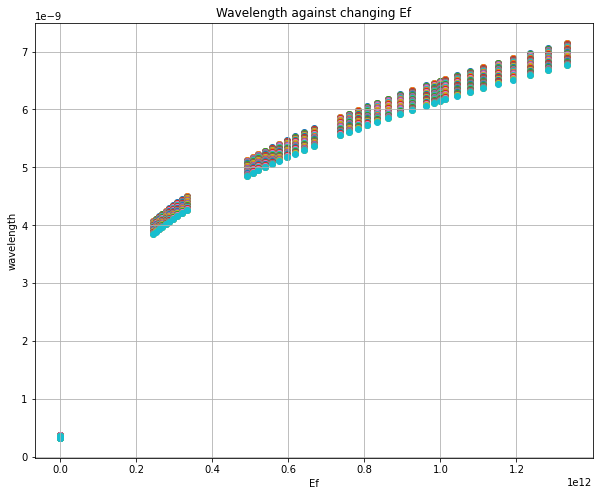

In [76]:
fig = plt.figure(figsize = (10,8))
E_G_3D = np.linspace(0.8e12, 1.2e8, 5)
EF_GRAPHENE = E_finder(E_G_3D,v_G)

for Es in E_Cu:
    lambd = []
    #print(Es)
    for Ef in EF_GRAPHENE:
        #print(Ef)
        wl = fun(t_G_sus,Ef,Es)
        lambd.append(wl)
    plt.scatter(EF_GRAPHENE, lambd)
plt.grid()
plt.title('Wavelength against changing Ef')
plt.xlabel('Ef')
plt.ylabel('wavelength')


# weirdxp1 = []
# weirdxp2 = []
# weirdxn = []
# for i in range(len(lambd)-2):
#     if lambd[i+1]-lambd[i] > lambd[i+1] - lambd[i+2]:
#         weirdxp1.append(EF_GRAPHENE[i])
#     elif lambd[i+1]-lambd[i] < lambd[i+1] - lambd[i+2]:
#         weirdxp2.append(EF_GRAPHENE[i])
#     elif lambd[i+2] - lambd[i+1] < lambd[i]-lambd[i+1]:
#         weirdxn.append(EF_GRAPHENE[i])

# print(weirdxn)
# print(weirdxp1)
# print(weirdxp2)

# for x1, x2 in zip(weirdxp1, weirdxp2):
#     plt.axvline(x1, color = 'green')
#     plt.axvline(x2, color = 'blue')
# plt.show()



Keep Ef and thickness constant 
For a given Ef, how does Es change the graph?

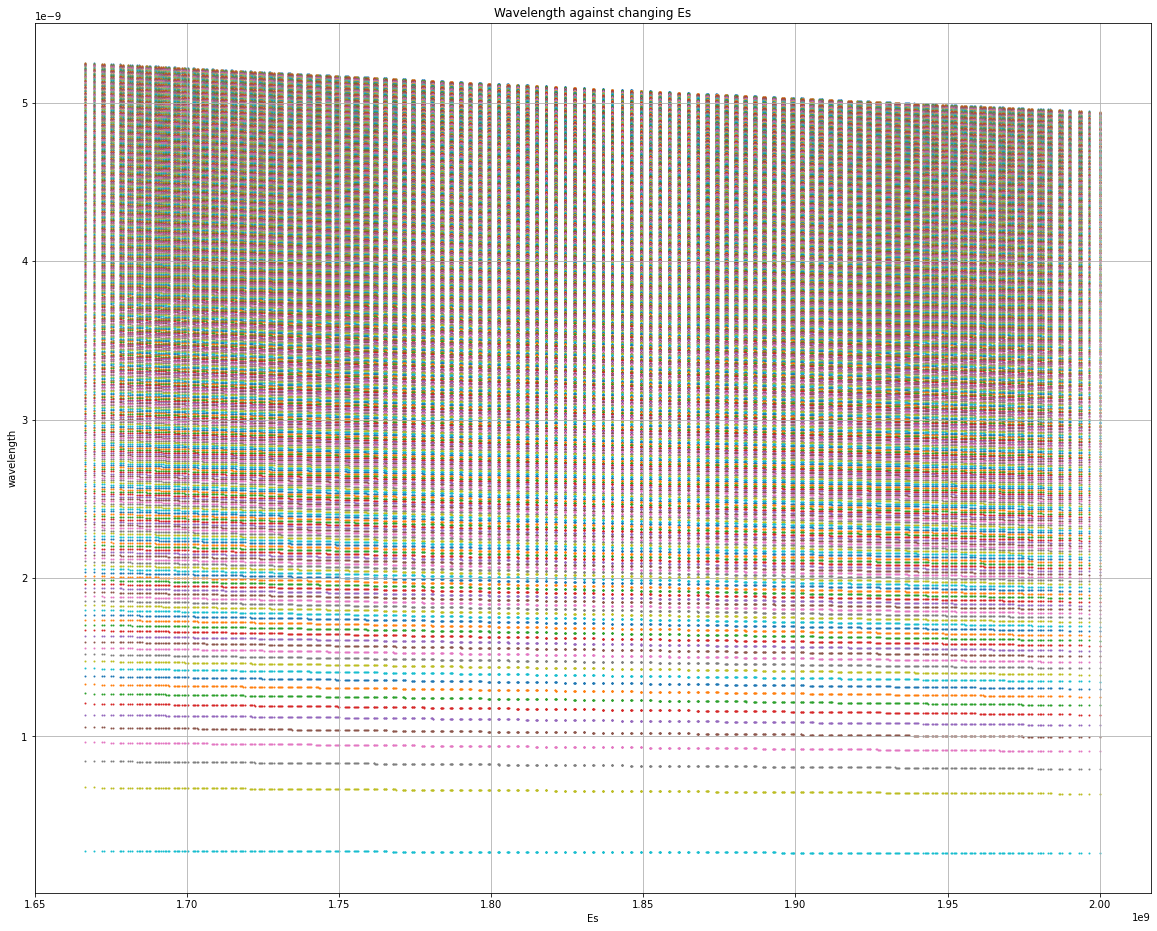

In [86]:
fig = plt.figure(figsize = (20,16))
E_G_3D = np.linspace(0.8e12, 1.2e8, 500)
EF_COPPER = E_finder(E_Cu,v_Cu)

for Ef in E_G_3D:
    lambd = []
    #print(Es)
    for Es in EF_COPPER:
        #print(Ef)
        wl = fun(t_G_sus,Ef,Es)
        lambd.append(wl)
    plt.scatter(EF_COPPER, lambd, s = 1)
plt.grid()
plt.title('Wavelength against changing Es')
plt.xlabel('Es')
plt.ylabel('wavelength')

plt.show()


In [82]:
len(v_Cu)

10

In [83]:
def allstuff(E,Es,v,t):
    B = []
    for x, y in zip(E,Es):
        A = x/y
        for pr in v:
            a = 2 * np.pi * t * (A/(3*(1-pr)))**(1/3)
            B.append(a)
    return B
    
            

In [85]:
E_G_3D = np.linspace(0.8e12, 1.2e8, 500)
EF_COPPER = E_finder(E_Cu,v_Cu)